In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.preprocessing
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
df=pd.read_excel('Physics_11th_filled.xlsx')

In [3]:
df.head()

,Year,Topic_id,Topic,Appeared,Chapter_Name
0,2025,C1-1,Physics and its Scope,0,Measurements
1,2025,C1-2,System International(SI),1,Measurements
2,2025,C1-3,Base Unit,0,Measurements
3,2025,C1-4,Derived Unit,0,Measurements
4,2025,C1-5,Supplementary Unit,0,Measurements


In [4]:
df.isnull().sum()

Year            0
Topic_id        0
Topic           0
Appeared        0
Chapter_Name    0
dtype: int64

In [5]:
df['Chapter_Name'].unique()

array(['Measurements', 'Vectors and Equilibrium', 'Forces and Motion',
       'Work and Energy', 'Rotattional and Circular Motion',
       'Fluid Dynamics', 'Oscillations', 'Waves', 'Physical Optics',
       'Thermodynamics'], dtype=object)

In [6]:
chapter_weight_map = {
    'Measurements':                    0.085,
    'Vectors and Equilibrium':         0.104,
    'Forces and Motion':               0.113,
    'Work and Energy':                 0.104,
    'Rotattional and Circular Motion': 0.113,
    'Fluid Dynamics':                  0.085,
    'Oscillations':                    0.094,
    'Waves':                           0.123,
    'Physical Optics':                 0.085,
    'Thermodynamics':                  0.094,
}

In [7]:
df['chapter_weight'] = df['Chapter_Name'].map(chapter_weight_map)

In [8]:
df = df.sort_values(['Topic', 'Year']).reset_index(drop=True)

In [9]:
available_years = sorted(df['Year'].unique())

gaps = []
last_idx_appeared = {}
for _, row in df.iterrows():
    exercise = row['Topic']
    year = row['Year']
    appeared = row['Appeared']
    
    current_idx = available_years.index(year)
    
    if exercise not in last_idx_appeared:
        gaps.append(-1)
    else:
        gaps.append(current_idx - last_idx_appeared[exercise])
    
    if appeared == 1:
        last_idx_appeared[exercise] = current_idx

df['Gaps'] = gaps

In [10]:
years_in_data = df['Year'].unique()

frequency = []

for _, row in df.iterrows():
    topic = row['Topic']
    year = row['Year']
    
    # Pichle 5 available years nikalo (current year se pehle)
    prev_years = [y for y in years_in_data if y < year]
    last_5_years = prev_years[-5:]
    
    # Us topic ki un years mein appeared values nikalo
    topic_data = df[df['Topic'] == topic]
    count = topic_data[topic_data['Year'].isin(last_5_years)]['Appeared'].sum()
    
    frequency.append(int(count))

df['Frequency_Last_5'] = frequency

In [11]:
df['Appeared_last_year'] = df.groupby('Topic')['Appeared'].shift(1).fillna(0).astype(int)

In [12]:
df['rolling_3'] = (df.groupby('Topic')['Appeared']
                   .transform(lambda x: x.shift(1).rolling(3).sum())
                   .fillna(0))

In [13]:
df.isnull().sum()

Year                  0
Topic_id              0
Topic                 0
Appeared              0
Chapter_Name          0
chapter_weight        0
Gaps                  0
Frequency_Last_5      0
Appeared_last_year    0
rolling_3             0
dtype: int64

In [14]:
df_model=df.copy()

## Train Test Split
Here we'll experiment to check how well our model understands pattern that's why we train data on ```2024,2023,2022,2019,2018,2017,2016``` and test on the paper of ```2025```

In [15]:
train = df_model[df_model['Year'] < 2025]
test  = df_model[df_model['Year'] == 2025]

features = ['Gaps', 'Frequency_Last_5','Appeared_last_year','rolling_3','chapter_weight']
targets = 'Appeared'

X_train = train[features]
y_train = train[targets]

X_test = test[features]
y_test = test[targets]

## Baseline Model
  ### ***. LogisticRegression***

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [17]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

### Accuracy , Precision , Recall

In [18]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
y_prob_lr = pipe.predict_proba(X_test)[:, 1]
accuracy_lr = accuracy_score(y_test, y_pred)
precision_lr = precision_score(y_test, y_pred)
recall_lr = recall_score(y_test, y_pred)
print(f"Accuracy:  {accuracy_lr * 100:.2f}%")
print(f'Precision:{precision_lr*100:.2f}%')
print(f'Recall:{recall_lr*100:.2f}%')

Accuracy:  60.40%
Precision:40.48%
Recall:79.07%


## Dummy Classifier

In [19]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(f"Dummy Accuracy: {accuracy_score(y_test, dummy.predict(X_test)):.4f}")

Dummy Accuracy: 0.7114


### Accuarcy , Classification Report On Different Threshold

In [20]:
from sklearn.metrics import classification_report

y_prob_lr = pipe.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.25]:
    y_pred_thresh = (y_prob_lr >= threshold).astype(int)
    print(f'Accuracy:{accuracy_score(y_test,y_pred_thresh)*100:.2f}%')
    print(f"\nThreshold={threshold}")
    print(classification_report(y_test, y_pred_thresh))

Accuracy:60.40%

Threshold=0.5
              precision    recall  f1-score   support

           0       0.86      0.53      0.65       106
           1       0.40      0.79      0.54        43

    accuracy                           0.60       149
   macro avg       0.63      0.66      0.60       149
weighted avg       0.73      0.60      0.62       149

Accuracy:55.70%

Threshold=0.4
              precision    recall  f1-score   support

           0       0.87      0.44      0.59       106
           1       0.38      0.84      0.52        43

    accuracy                           0.56       149
   macro avg       0.62      0.64      0.55       149
weighted avg       0.73      0.56      0.57       149

Accuracy:35.57%

Threshold=0.3
              precision    recall  f1-score   support

           0       0.92      0.10      0.19       106
           1       0.31      0.98      0.47        43

    accuracy                           0.36       149
   macro avg       0.61      0.54  

c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### Prediction For 2026

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1 - Full data pe train karo
features = ['Gaps', 'Frequency_Last_5', 'Appeared_last_year', 'rolling_3', 'chapter_weight']
targets = 'Appeared'

X_full = df_model[features].copy()
y_full = df_model[targets]

pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe_full.fit(X_full, y_full)

# Step 2 - 2026 ka base
df_2026 = df[df['Year'] == 2025][['Topic_id', 'Topic', 'Chapter_Name', 'Appeared', 'Gaps',
              'Frequency_Last_5', 'Appeared_last_year',
              'rolling_3', 'chapter_weight']].copy()
df_2026['Year'] = 2026

# Step 3 - Features update
df_2026['Appeared_last_year'] = df_2026['Appeared']
df_2026['Gaps'] = df_2026.apply(
    lambda row: 1 if row['Appeared'] == 1 else row['Gaps'] + 1, axis=1)
df_2026['Frequency_Last_5'] = df_2026.apply(
    lambda row: min(5, row['Frequency_Last_5'] + row['Appeared']), axis=1)
df_2026['rolling_3'] = df_2026.apply(
    lambda row: min(3, row['rolling_3'] + row['Appeared']), axis=1)

# Step 4 - Predict
X_2026 = df_2026[features].copy()
prob_2026 = pipe_full.predict_proba(X_2026)[:, 1]
df_2026['Probability'] = prob_2026

# Step 5 - Filter + Category
result_2026 = df_2026[['Topic_id', 'Topic', 'Chapter_Name', 'Probability']]\
              .sort_values('Probability', ascending=False)\
              .reset_index(drop=True)

final_predictions = result_2026[result_2026['Probability'] >= 0.5].head(25).copy()

final_predictions['Category'] = final_predictions['Probability'].apply(
    lambda x: 'A - Must Prepare' if x >= 0.7 else 'B - Should Prepare'
)

# Step 6 - Years appeared nikalo
appeared_years_list = []
for _, row in final_predictions.iterrows():
    topic = row['Topic']
    years = df[
        (df['Topic'] == topic) &
        (df['Appeared'] == 1)
    ]['Year'].tolist()
    appeared_years_list.append(', '.join(map(str, sorted(years))))

final_predictions['Years_Appeared'] = appeared_years_list
final_predictions['Total_Appearances'] = final_predictions['Years_Appeared'].apply(
    lambda x: len(x.split(', ')) if x else 0
)

# Step 7 - Save
final_predictions.to_excel('Physics_1stYear_Predictions_2026.xlsx', index=False)
print(final_predictions)

   Topic_id                                Topic  \
0     C1-13    Dimensions of Physical Quantities   
1     C7-10       Simple Harmonic Motion( S H M)   
2      C2-7                   Product of Vectors   
3      C4-7                      Escape Velocity   
4      C2-3                  Addition of Vectors   
5      C4-1                                 Work   
6      C6-7  Application of Bernoulli's Equation   
7     C1-12               Precision and Accuracy   
8     C3-15                    Projectile Motion   
9      C5-9         Torque and Moment of Inertia   
10    C10-2                      Internal Energy   
11     C6-3                    Terminal Velocity   
12     C4-3                                Power   
13     C6-4                           Fluid Flow   
14     C1-2             System International(SI)   
15    C7-13   Energy Conservation in case of SHM   
16    C10-7          First Lawnof Thermodynamics   
17     C8-6             Characteristics of Waves   
18     C8-7 

In [22]:
# final_predictions.to_excel('Predicted_Physics_Topics_Class_11th_2026.xlsx', index=False)
# print("File saved!")

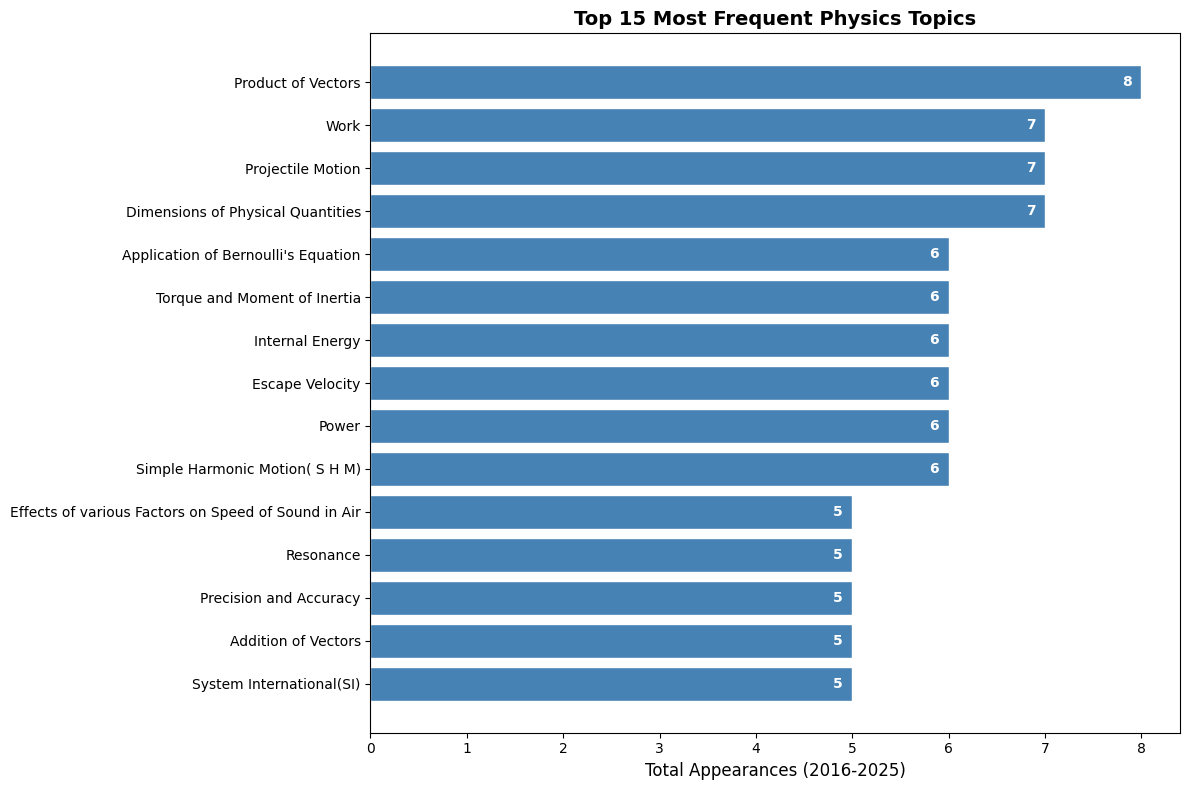

In [23]:
import matplotlib.pyplot as plt

topic_freq = df.groupby('Topic')['Appeared'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(topic_freq.index, topic_freq.values, color='steelblue', edgecolor='white')
plt.xlabel('Total Appearances (2016-2025)', fontsize=12)
plt.title('Top 15 Most Frequent Physics Topics', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Values bar ke andar dikhao
for bar, val in zip(bars, topic_freq.values):
    plt.text(val - 0.1, bar.get_y() + bar.get_height()/2, 
             str(int(val)), va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph1_frequency.png', dpi=150)
plt.show()

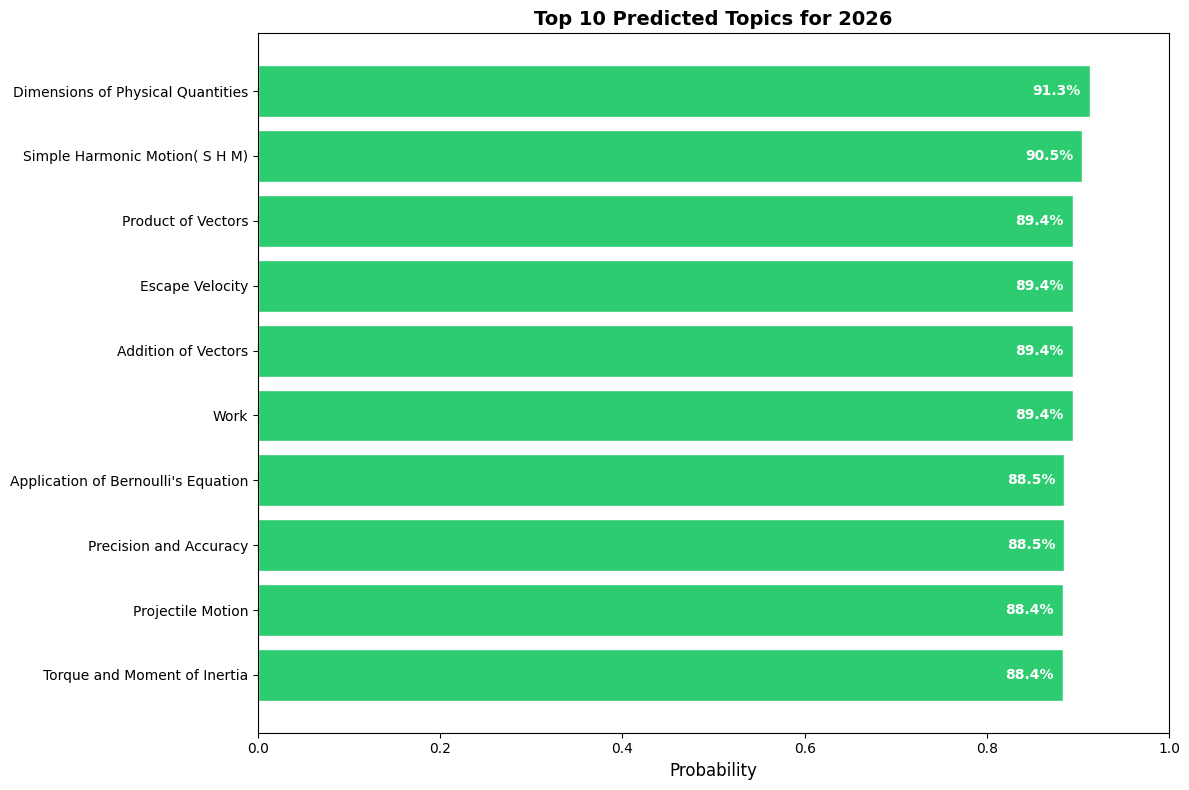

In [24]:
top10 = result_2026.head(10)

plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if p >= 0.85 else '#f39c12' if p >= 0.80 else '#e74c3c' 
          for p in top10['Probability']]
bars = plt.barh(top10['Topic'], top10['Probability'], color=colors, edgecolor='white')
plt.xlabel('Probability', fontsize=12)
plt.title('Top 10 Predicted Topics for 2026', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.gca().invert_yaxis()

for bar, val in zip(bars, top10['Probability']):
    plt.text(val - 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph2_predictions.png', dpi=150)
plt.show()

In [25]:
probs = pipe_full.predict_proba(X_2026)[:, 1]
for thresh in [0.4, 0.5, 0.6, 0.7]:
    count = (probs >= thresh).sum()
    print(f"Threshold {thresh}: {count} topics predicted")

Threshold 0.4: 102 topics predicted
Threshold 0.5: 94 topics predicted
Threshold 0.6: 77 topics predicted
Threshold 0.7: 44 topics predicted


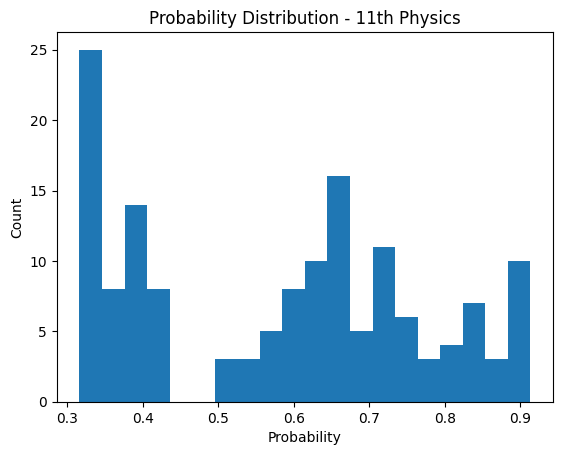

In [26]:
import matplotlib.pyplot as plt
plt.hist(probs, bins=20)
plt.title('Probability Distribution - 11th Physics')
plt.xlabel('Probability')
plt.ylabel('Count')
plt.show()

In [27]:
result_2026 = df_2026[['Topic_id', 'Topic', 'Probability']]\
    .sort_values('Probability', ascending=False)\
    .reset_index(drop=True)

# Filter: ≥0.5 threshold, top 25 max
final_predictions = result_2026[result_2026['Probability'] >= 0.5].head(25)
print(final_predictions)

   Topic_id                                Topic  Probability
0     C1-13    Dimensions of Physical Quantities     0.913368
1     C7-10       Simple Harmonic Motion( S H M)     0.904711
2      C2-7                   Product of Vectors     0.894191
3      C4-7                      Escape Velocity     0.894191
4      C2-3                  Addition of Vectors     0.894191
5      C4-1                                 Work     0.894191
6      C6-7  Application of Bernoulli's Equation     0.885129
7     C1-12               Precision and Accuracy     0.885129
8     C3-15                    Projectile Motion     0.883862
9      C5-9         Torque and Moment of Inertia     0.883862
10    C10-2                      Internal Energy     0.874039
11     C6-3                    Terminal Velocity     0.870457
12     C4-3                                Power     0.860656
13     C6-4                           Fluid Flow     0.849206
14     C1-2             System International(SI)     0.849206
15    C7

In [28]:
print(final_predictions['Probability'].value_counts().head(10))

Probability
0.894191    4
0.831958    2
0.885129    2
0.883862    2
0.849206    2
0.835293    2
0.913368    1
0.904711    1
0.874039    1
0.860656    1
Name: count, dtype: int64
